In [2]:
import numpy as np
from qiskit import *
from component.ibm_simulator.sim_machine5qubits import *
import mapomatic as mm
backend = FakeAthensV2()

In [3]:
print(backend.configuration().coupling_map)

[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]


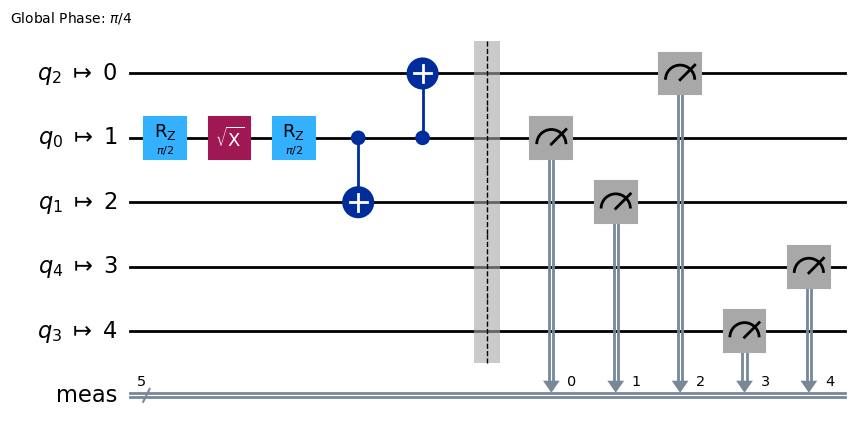

In [4]:
small_qc = QuantumCircuit(5)
small_qc.h(0)
small_qc.cx(0,1)
small_qc.cx(0,2)
small_qc.measure_all()
trans_qc = transpile(small_qc, backend)
trans_qc.draw("mpl")

In [5]:
layouts = mm.matching_layouts(trans_qc, backend)
print(layouts)

[[2, 1, 0, 3, 4], [2, 1, 0, 4, 3], [0, 1, 2, 3, 4], [0, 1, 2, 4, 3], [1, 2, 3, 0, 4], [1, 2, 3, 4, 0], [3, 2, 1, 0, 4], [3, 2, 1, 4, 0], [2, 3, 4, 1, 0], [2, 3, 4, 0, 1], [4, 3, 2, 1, 0], [4, 3, 2, 0, 1]]


In [8]:
scores = mm.evaluate_layouts(trans_qc, layouts, backend)
print(scores)
print(scores[0][0])

[([2, 1, 0, 3, 4], 0.09837431352515102), ([2, 1, 0, 4, 3], 0.09837431352515102), ([0, 1, 2, 3, 4], 0.09837431352515114), ([0, 1, 2, 4, 3], 0.09837431352515114), ([3, 2, 1, 4, 0], 0.11141941518348719), ([1, 2, 3, 4, 0], 0.1114194151834873), ([3, 2, 1, 0, 4], 0.1114194151834873), ([1, 2, 3, 0, 4], 0.11141941518348741), ([2, 3, 4, 1, 0], 0.12119521712387338), ([4, 3, 2, 1, 0], 0.12119521712387338), ([2, 3, 4, 0, 1], 0.12119521712387349), ([4, 3, 2, 0, 1], 0.12119521712387349)]
[2, 1, 0, 3, 4]


In [3]:
import copy

# Shallow Copy - nested objects are shared
original = [[1, 2], [3, 4]]
shallow = copy.copy(original)
shallow[0][0] = 999
print("Shallow Copy:")
print(f"Original: {original}")  # AFFECTED: [[999, 2], [3, 4]]
print(f"Shallow:  {shallow}")   # [[999, 2], [3, 4]]

# Deep Copy - completely independent
original = [[1, 2], [3, 4]]
deep = copy.deepcopy(original)
deep[0][0] = 999
print("\nDeep Copy:")
print(f"Original: {original}")  # NOT affected: [[1, 2], [3, 4]]
print(f"Deep:     {deep}")      # [[999, 2], [3, 4]]

# Check object identity
print("\nObject Identity:")
print(f"original[0] is shallow[0]: {original[0] is shallow[0]}")  # True - same reference
print(f"original[0] is deep[0]: {original[0] is deep[0]}")        # False - different copies

Shallow Copy:
Original: [[999, 2], [3, 4]]
Shallow:  [[999, 2], [3, 4]]

Deep Copy:
Original: [[1, 2], [3, 4]]
Deep:     [[999, 2], [3, 4]]

Object Identity:
original[0] is shallow[0]: False
original[0] is deep[0]: False
